In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision.transforms import v2
import os
import matplotlib.pyplot as plt
import random

In [2]:
class LeNet1(nn.Module):
  def __init__(self):
    super().__init__()
    self.H1 = nn.Conv2d(in_channels=1,
                        out_channels=12,
                        kernel_size=5,
                        stride=2,
                        padding=2,
                        padding_mode="zeros")
    self.H2 = nn.Conv2d(in_channels=12,
                        out_channels=12,
                        kernel_size=5,
                        stride=2,
                        padding=2,
                        padding_mode="zeros")
    self.H3 = nn.Sequential(nn.Flatten(),
                            nn.Linear(in_features=192,
                                      out_features=30))
    self.output = nn.Linear(in_features=30,
                            out_features=10)

  def forward(self, x):
    x = self.H1(x)
    x = self.H2(x)
    x = self.H3(x)
    x = self.output(x)
    return x

In [3]:
transform = v2.Compose([
    v2.Resize((16,16)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    ])

In [4]:
train_data = torchvision.datasets.MNIST(root="data",
                                        train=True,
                                        transform=transform,
                                        download=True)
test_data = torchvision.datasets.MNIST(root="data",
                                       train=False,
                                       transform=transform,
                                       download=True)

In [5]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)
test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)

(np.float64(-0.5), np.float64(15.5), np.float64(15.5), np.float64(-0.5))

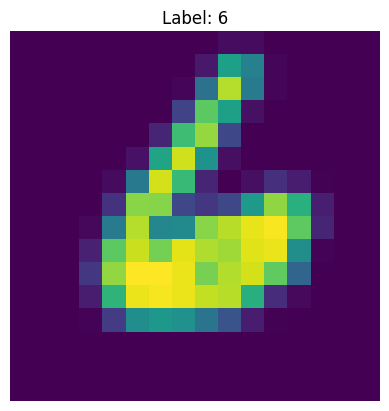

In [6]:
first_batch = next(iter(train_dataloader))
img = first_batch[0][0]
label = first_batch[1][0]
plt.title(f"Label: {label}")
plt.imshow(img.squeeze())
plt.axis("off")

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [8]:
model = LeNet1().to(device)
model

LeNet1(
  (H1): Conv2d(1, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (H2): Conv2d(12, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (H3): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=192, out_features=30, bias=True)
  )
  (output): Linear(in_features=30, out_features=10, bias=True)
)

In [9]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),
                              lr=0.01)

In [10]:
from numpy.matrixlib import test
EPOCHS = 1

model.train()
for epoch in range(EPOCHS):
  batch_loss, batch_accuracy = 0, 0
  test_batch_loss, test_batch_accuracy = 0, 0

  for batch, (X_train, y_train) in enumerate(train_dataloader):
    X_train, y_train = X_train.to(device), y_train.to(device)

    logit = model(X_train)

    loss = loss_fn(logit, y_train)
    batch_loss += loss

    accuracy = torch.sum(torch.argmax(torch.softmax(logit, dim=1), dim=1) == y_train) / len(y_train)
    batch_accuracy += accuracy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      print(f"Batch: {batch} | Train loss: {loss} | Train accuracy: {accuracy}")

  batch_loss /= len(train_dataloader)
  batch_accuracy /= len(train_dataloader)
  print(f"Epoch: {epoch} | Train Batch loss: {batch_loss} | Train accuracy loss: {batch_accuracy}")

  model.eval()
  for batch, (X_test, y_test) in enumerate(test_dataloader):
    X_test, y_test = X_test.to(device), y_test.to(device)

    test_logit = model(X_test)

    test_loss = loss_fn(test_logit, y_test)
    test_batch_loss += test_loss

    test_accuracy = torch.sum(torch.argmax(torch.softmax(test_logit, dim=1), dim=1) == y_test) / len(y_test)
    test_batch_accuracy += test_accuracy

    if batch % 100 == 0:
      print(f"Batch: {batch} | Test loss: {test_loss} | Test accuracy: {test_accuracy}")

  test_batch_loss /= len(test_dataloader)
  test_batch_accuracy /= len(test_dataloader)
  print(f"Epoch: {epoch} | Test batch loss: {test_batch_loss} | Test batch accuracy: {test_batch_accuracy}")


Batch: 0 | Train loss: 2.305070638656616 | Train accuracy: 0.15625
Batch: 100 | Train loss: 2.2756118774414062 | Train accuracy: 0.09375
Batch: 200 | Train loss: 2.2792084217071533 | Train accuracy: 0.15625
Batch: 300 | Train loss: 2.2024307250976562 | Train accuracy: 0.34375
Batch: 400 | Train loss: 2.138598680496216 | Train accuracy: 0.375
Batch: 500 | Train loss: 1.9211599826812744 | Train accuracy: 0.4375
Batch: 600 | Train loss: 1.5439924001693726 | Train accuracy: 0.65625
Batch: 700 | Train loss: 1.0154914855957031 | Train accuracy: 0.75
Batch: 800 | Train loss: 0.8566693067550659 | Train accuracy: 0.75
Batch: 900 | Train loss: 0.7730967998504639 | Train accuracy: 0.84375
Batch: 1000 | Train loss: 0.5381075143814087 | Train accuracy: 0.78125
Batch: 1100 | Train loss: 0.39309683442115784 | Train accuracy: 0.9375
Batch: 1200 | Train loss: 0.6602118611335754 | Train accuracy: 0.75
Batch: 1300 | Train loss: 0.6983684301376343 | Train accuracy: 0.84375
Batch: 1400 | Train loss: 0.4291

(np.float64(-0.5), np.float64(15.5), np.float64(15.5), np.float64(-0.5))

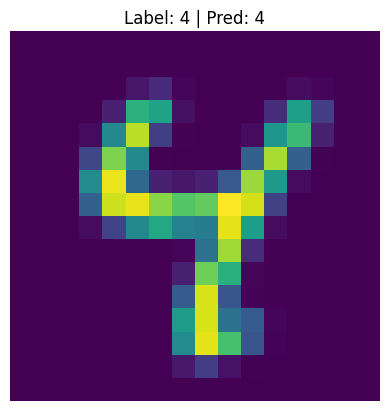

In [22]:
idx = random.randint(0, 31)
test_batch = next(iter(test_dataloader))
test_img = test_batch[0][idx]
test_label = test_batch[1][idx]

model.eval()
with torch.inference_mode():
  logit = model(test_img.unsqueeze(dim=0).to(device))
  pred = torch.argmax(torch.softmax(logit, dim=1), dim=1)

plt.title(f"Label: {test_label} | Pred: {pred.item()}")
plt.imshow(test_img.squeeze())
plt.axis("off")